In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [3]:
def relative_perm(sw, swi, sor, nw, no, kwo, koo):
    
    S = (sw - swi) / (1 - swi - sor)

    if S <= 0:
        kw = 0
    elif S >= 1:
        kw = kwo
    else:
        kw = kwo * S ** nw

    if S <= 0:
        ko = koo
    elif S >= 1:
        ko = 0
    else:
        ko = koo * (1 - S) ** no
    
    return kw, ko

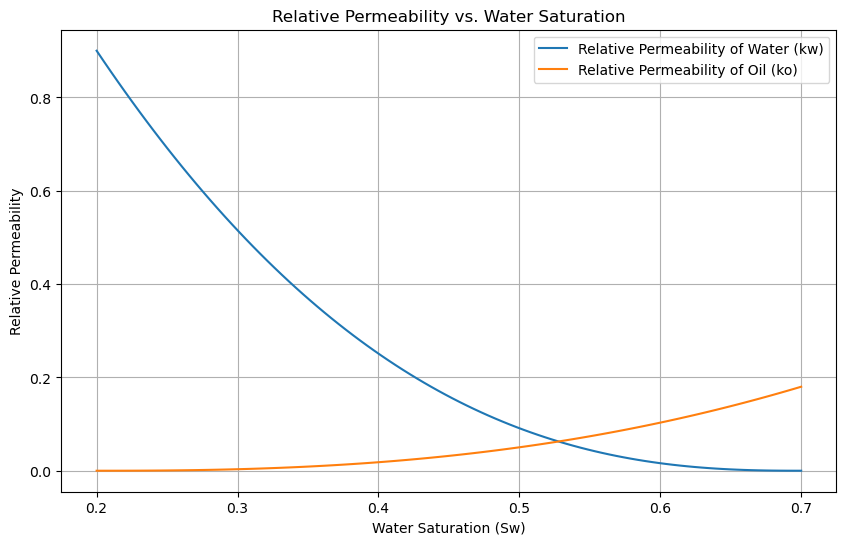

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def relative_perm(sw, swi, sor, nw, no, kwo, koo):
    
    S = (sw - swi) / (1 - swi - sor)

    S = max(0, min(S, 1))

    if S <= 0:
        kw = kwo 
    elif S >= 1:
        kw = 0  
    else:
        kw = kwo * (1 - S) ** nw 

    if S <= 0:
        ko = 0 
    elif S >= 1:
        ko = koo 
    else:
        ko = koo * S ** no 
    
    return kw, ko

# Parameters
swi = 0.2 
sor = 0.3 
nw = 2.5 
no = 2.5  
kwo = 0.9 
koo = 0.18 

sw_values = np.linspace(swi, 1 - sor, 100)

kw_values = []
ko_values = []
for sw in sw_values:
    kw, ko = relative_perm(sw, swi, sor, nw, no, kwo, koo)
    kw_values.append(kw)
    ko_values.append(ko)

plt.figure(figsize=(10, 6))
plt.plot(sw_values, kw_values, label='Relative Permeability of Water (kw)')
plt.plot(sw_values, ko_values, label='Relative Permeability of Oil (ko)')
plt.xlabel('Water Saturation (Sw)')
plt.ylabel('Relative Permeability')
plt.title('Relative Permeability vs. Water Saturation')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
import numpy as np

def relative_permeabilities(Sw, Swi, Sor, nw, no, kwo, koo):
    """
    Compute relative permeabilities for water and oil.
    """
    S = (Sw - Swi) / (1 - Swi - Sor)
    S = max(0, min(S, 1))

    if S <= 0:
        kw = kwo
    elif S >= 1:
        kw = 0
    else:
        kw = kwo * (1 - S) ** nw

    if S <= 0:
        ko = 0
    elif S >= 1:
        ko = koo
    else:
        ko = koo * S ** no

    return kw, ko

def fractional_flow(Sw, Swi, Sor, nw, no, kwo, koo, mu_w, mu_o):
    """
    Compute the fractional flow of water.
    """
    kw, ko = relative_permeabilities(Sw, Swi, Sor, nw, no, kwo, koo)
    if kw == 0:
        return 0  # No water flow if kw is zero
    lambda_w = kw / mu_w
    lambda_o = ko / mu_o
    fw = 1 / (1 + lambda_o / lambda_w)
    return fw

def fractional_flow_derivative(Sw, Swi, Sor, nw, no, kwo, koo, mu_w, mu_o, delta=1e-6):
    """
    Compute the derivative of the fractional flow of water with respect to Sw.
    """
    fw1 = fractional_flow(Sw, Swi, Sor, nw, no, kwo, koo, mu_w, mu_o)
    fw2 = fractional_flow(Sw + delta, Swi, Sor, nw, no, kwo, koo, mu_w, mu_o)
    dfw_dSw = (fw2 - fw1) / delta
    return dfw_dSw

fw = fractional_flow(Sw, Swi, Sor, nw, no, kwo, koo, mu_w, mu_o)
dfw_dSw = fractional_flow_derivative(Sw, Swi, Sor, nw, no, kwo, koo, mu_w, mu_o)

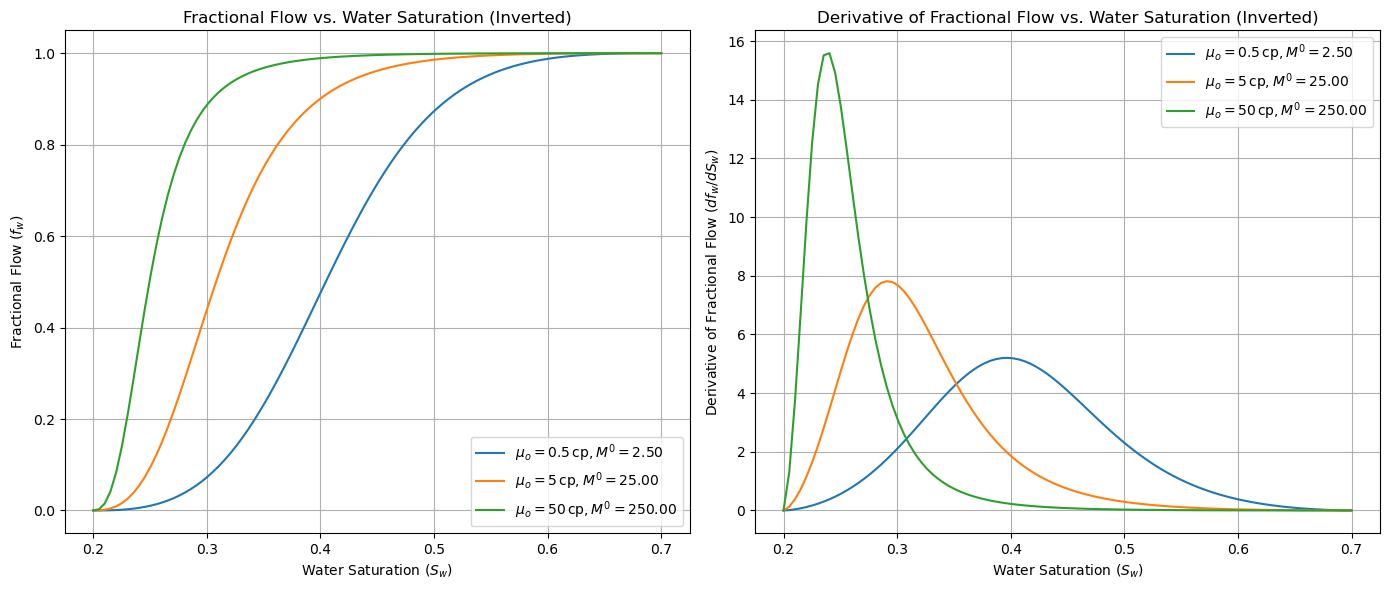

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def relative_permeabilities(Sw, Swi, Sor, nw, no, kwo, koo):
    """
    Compute INVERTED relative permeabilities for water and oil.
    """
    S = (Sw - Swi) / (1 - Swi - Sor)
    S = max(0, min(S, 1))

    if S <= 0:
        kw = 0
    elif S >= 1:
        kw = kwo
    else:
        kw = kwo * S ** nw  # Inverted: kw increases with Sw

    if S <= 0:
        ko = koo
    elif S >= 1:
        ko = 0
    else:
        ko = koo * (1 - S) ** no  # Inverted: ko decreases with Sw

    return kw, ko

def fractional_flow(Sw, Swi, Sor, nw, no, kwo, koo, mu_w, mu_o):
    """
    Compute the fractional flow of water using INVERTED relative permeabilities.
    """
    kw, ko = relative_permeabilities(Sw, Swi, Sor, nw, no, kwo, koo)
    if kw == 0:
        return 0  # No water flow if kw is zero
    lambda_w = kw / mu_w
    lambda_o = ko / mu_o
    fw = 1 / (1 + lambda_o / lambda_w)
    return fw

def fractional_flow_derivative(Sw, Swi, Sor, nw, no, kwo, koo, mu_w, mu_o, delta=1e-6):
    """
    Compute the derivative of the fractional flow of water with respect to Sw.
    """
    fw1 = fractional_flow(Sw, Swi, Sor, nw, no, kwo, koo, mu_w, mu_o)
    fw2 = fractional_flow(Sw + delta, Swi, Sor, nw, no, kwo, koo, mu_w, mu_o)
    dfw_dSw = (fw2 - fw1) / delta
    return dfw_dSw

# Extracted Parameters
Swi = 0.2  # Irreducible water saturation
Sor = 0.3  # Residual oil saturation
nw = 2.5   # Exponent for water relative permeability
no = 2.5   # Exponent for oil relative permeability
kwo = 0.9  # Endpoint relative permeability for water
koo = 0.18 # Endpoint relative permeability for oil
mu_w = 1.0 # Water viscosity
mu_o_values = [0.5, 5, 50]  # Oil viscosities to compare
u = 0.01   # Darcy velocity (ft/day)
k = 500    # Permeability (mD)
rho_w = 62.4  # Water density (lb_m/ft^3)
rho_o = 35    # Oil density (lb_m/ft^3)
alpha = 0     # Dipping angle (degrees)

# Water saturation range
Sw_values = np.linspace(Swi, 1 - Sor, 100)

# Plotting
plt.figure(figsize=(14, 6))

# Plot 1: Fractional Flow vs. Water Saturation
plt.subplot(1, 2, 1)
for mu_o in mu_o_values:
    fw_values = [fractional_flow(Sw, Swi, Sor, nw, no, kwo, koo, mu_w, mu_o) for Sw in Sw_values]
    M0 = (kwo / mu_w) / (koo / mu_o)  # Endpoint mobility ratio
    plt.plot(Sw_values, fw_values, label=fr'$\mu_o = {mu_o} \, \text{{cp}}, M^0 = {M0:.2f}$')

plt.xlabel('Water Saturation ($S_w$)')
plt.ylabel('Fractional Flow ($f_w$)')
plt.title('Fractional Flow vs. Water Saturation (Inverted)')
plt.legend()
plt.grid(True)

# Plot 2: Derivative of Fractional Flow vs. Water Saturation
plt.subplot(1, 2, 2)
for mu_o in mu_o_values:
    dfw_dSw_values = [fractional_flow_derivative(Sw, Swi, Sor, nw, no, kwo, koo, mu_w, mu_o) for Sw in Sw_values]
    M0 = (kwo / mu_w) / (koo / mu_o)  # Endpoint mobility ratio
    plt.plot(Sw_values, dfw_dSw_values, label=fr'$\mu_o = {mu_o} \, \text{{cp}}, M^0 = {M0:.2f}$')

plt.xlabel('Water Saturation ($S_w$)')
plt.ylabel('Derivative of Fractional Flow ($df_w/dS_w$)')
plt.title('Derivative of Fractional Flow vs. Water Saturation (Inverted)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

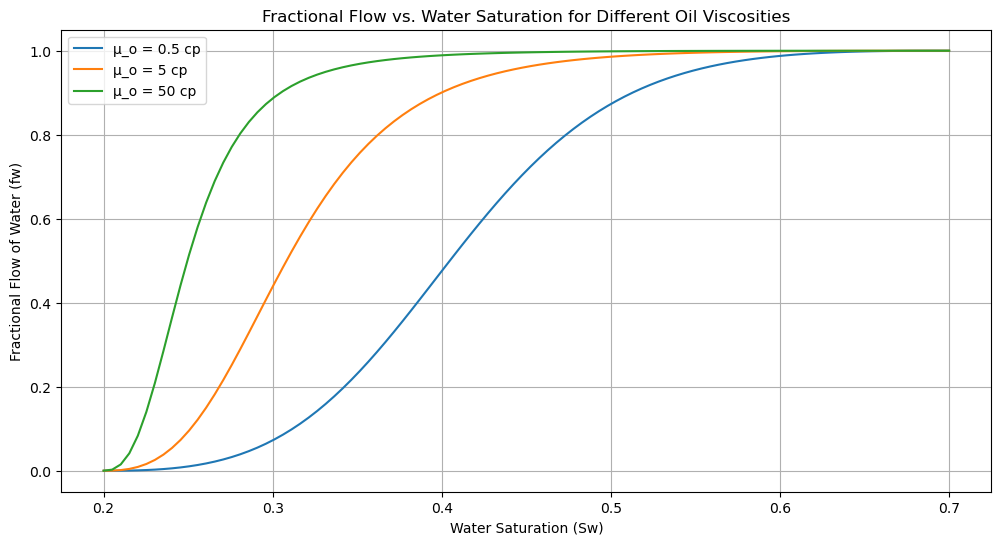

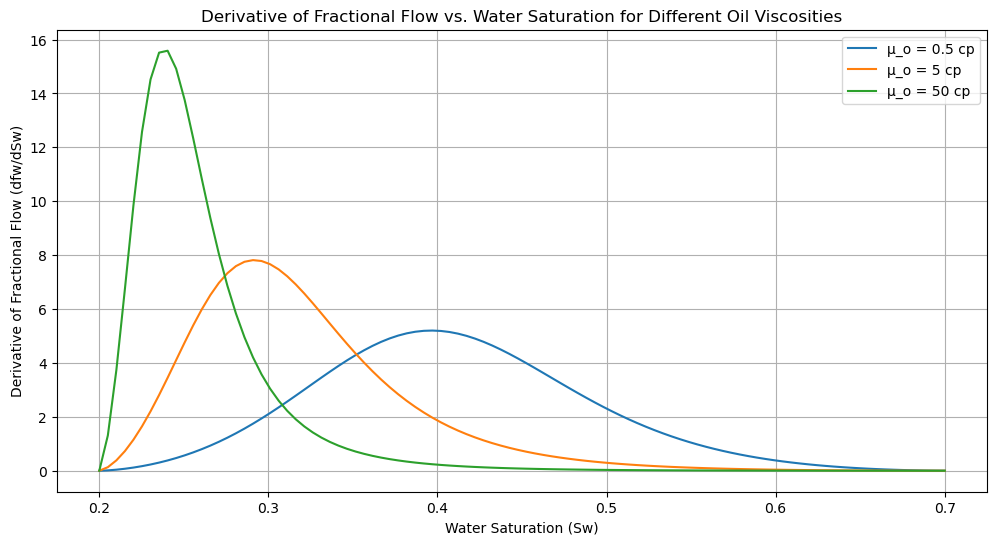

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def relative_permeabilities(Sw, Swi, Sor, nw, no, kwo, koo):
    """
    Compute INVERTED relative permeabilities for water and oil.
    """
    S = (Sw - Swi) / (1 - Swi - Sor)
    S = max(0, min(S, 1))

    if S <= 0:
        kw = 0
    elif S >= 1:
        kw = kwo
    else:
        kw = kwo * S ** nw  # Inverted: kw increases with Sw

    if S <= 0:
        ko = koo
    elif S >= 1:
        ko = 0
    else:
        ko = koo * (1 - S) ** no  # Inverted: ko decreases with Sw

    return kw, ko

def fractional_flow(Sw, Swi, Sor, nw, no, kwo, koo, mu_w, mu_o):
    """
    Compute the fractional flow of water using INVERTED relative permeabilities.
    """
    kw, ko = relative_permeabilities(Sw, Swi, Sor, nw, no, kwo, koo)
    if kw == 0:
        return 0  # No water flow if kw is zero
    lambda_w = kw / mu_w
    lambda_o = ko / mu_o
    fw = 1 / (1 + lambda_o / lambda_w)
    return fw

def fractional_flow_derivative(Sw, Swi, Sor, nw, no, kwo, koo, mu_w, mu_o, delta=1e-6):
    """
    Compute the derivative of the fractional flow of water with respect to Sw.
    """
    fw1 = fractional_flow(Sw, Swi, Sor, nw, no, kwo, koo, mu_w, mu_o)
    fw2 = fractional_flow(Sw + delta, Swi, Sor, nw, no, kwo, koo, mu_w, mu_o)
    dfw_dSw = (fw2 - fw1) / delta
    return dfw_dSw

# Given parameters
mu_w = 1.0  # cp
u = 0.01  # ft/day
k = 500  # mD
rho_w = 62.4  # lbm/ft^3
rho_o = 35  # lbm/ft^3
alpha = 0  # degrees

# Relative permeability parameters
Swi = 0.2  # Irreducible water saturation
Sor = 0.3  # Residual oil saturation
nw = 2.5   # Exponent for water relative permeability
no = 2.5   # Exponent for oil relative permeability
kwo = 0.9  # Endpoint relative permeability for water
koo = 0.18 # Endpoint relative permeability for oil

# Viscosities to compare
mu_o_list = [0.5, 5, 50]

# Water saturation range
Sw = np.linspace(Swi, 1 - Sor, 100)

# Plotting Fractional Flow vs. Water Saturation
plt.figure(figsize=(12, 6))
for mu_o in mu_o_list:
    fw_values = [fractional_flow(Sw_val, Swi, Sor, nw, no, kwo, koo, mu_w, mu_o) for Sw_val in Sw]
    plt.plot(Sw, fw_values, label=f'μ_o = {mu_o} cp')

plt.xlabel('Water Saturation (Sw)')
plt.ylabel('Fractional Flow of Water (fw)')
plt.title('Fractional Flow vs. Water Saturation for Different Oil Viscosities')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Derivative of Fractional Flow vs. Water Saturation
plt.figure(figsize=(12, 6))
for mu_o in mu_o_list:
    dfw_dSw_values = [fractional_flow_derivative(Sw_val, Swi, Sor, nw, no, kwo, koo, mu_w, mu_o) for Sw_val in Sw]
    plt.plot(Sw, dfw_dSw_values, label=f'μ_o = {mu_o} cp')

plt.xlabel('Water Saturation (Sw)')
plt.ylabel('Derivative of Fractional Flow (dfw/dSw)')
plt.title('Derivative of Fractional Flow vs. Water Saturation for Different Oil Viscosities')
plt.legend()
plt.grid(True)
plt.show()